# 04 - Transformer sentiment classifier and its explanations  (Req 2b, Req 7)

**Goal:** classify tweets as negative / neutral / positive with a transformer, measure how well it does on the hand-labelled tweets, and show *which words* led to each label.

Two transformer models:

| | Model | Training | Classes |
|---|---|---|---|
| **A** (main) | `cardiffnlp/twitter-roberta-base-sentiment-latest` | none by us - already fine-tuned on TweetEval | negative / neutral / positive |
| **B** | `distilbert-base-uncased` | fine-tuned by us on 20k emoticon-labelled tweets | negative / positive |

The work is done by `src/04`, `src/05` and `src/06`; this notebook runs them and shows the results.

**Run this on a GPU.** On Google Colab: *Runtime -> Change runtime type -> T4 GPU*, then *Run all* (about 10 minutes). On a laptop CPU, set `QUICK = True` below.

In [1]:
import os, sys, json, subprocess
BRANCH = 'transformer-classifier'   # the GitHub branch that has src/04-06 (use 'main' once merged)
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB and not os.path.exists('/content/NamPulse'):
    subprocess.run(['git', 'clone', '-b', BRANCH, 'https://github.com/AKChumba/NamPulse.git', '/content/NamPulse'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', '/content/NamPulse/requirements.txt'], check=True)
if IN_COLAB:
    os.chdir('/content/NamPulse/notebooks')
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display
import torch
pd.set_option('display.max_colwidth', 110)
print('GPU available:', torch.cuda.is_available())

QUICK = not torch.cuda.is_available()   # True = small runs that finish on a laptop CPU
RERUN = False                            # False = just load the saved reports

GPU available: True


## A. Pretrained Twitter-RoBERTa (no training)
Scores every tweet and evaluates on the 493 hand-labelled tweets (3 classes), then on the 354 positive/negative ones (to compare with the classical model).

In [2]:
if RERUN:
    args = '--limit 5000' if QUICK else ''
    !python ../src/04_transformer_pretrained.py {args}
print(open('../reports/transformer_pretrained_report.txt').read())

Model: cardiffnlp/twitter-roberta-base-sentiment-latest   device: cuda
Model classes: ['negative', 'neutral', 'positive']
Scoring 100,493 tweets (493 hand-labelled + 100,000 emoticon) ...
Done in 3.9 min (428 tweets/sec)

=== 1. Hand-labelled tweets (3 classes) ===
n = 493   {'positive': 179, 'negative': 175, 'neutral': 139}
Accuracy: 0.868   Macro-F1: 0.866
              precision    recall  f1-score   support

    negative      0.935     0.829     0.879       175
     neutral      0.825     0.849     0.837       139
    positive      0.846     0.922     0.882       179

    accuracy                          0.868       493
   macro avg      0.869     0.866     0.866       493
weighted avg      0.872     0.868     0.868       493

Confusion matrix (rows = true, columns = predicted):
          negative  neutral  positive
negative       145       14        16
neutral          7      118        14
positive         3       11       165

=== 2. Hand-labelled tweets, positive vs negative (c

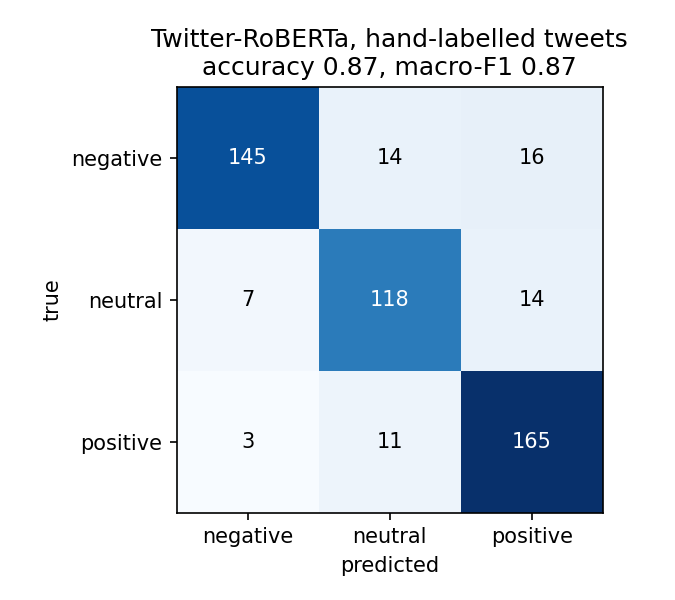

In [3]:
display(Image('../reports/transformer_pretrained_confusion.png', width=380))

## B. DistilBERT fine-tuned on our emoticon labels
Train/validation come from the emoticon-labelled tweets (each distinct text used once, nothing that is also in the test set). Test = the hand-labelled positive/negative tweets.

Base model: distilbert-base-uncased   device: cuda
Train 20,000  {'positive': 10034, 'negative': 9966}
Val   2,000  {'negative': 1034, 'positive': 966}
Test  354  {'positive': 179, 'negative': 175}  (hand-labelled)
Epoch 1: train loss 0.4721   val accuracy 0.803
Epoch 2: train loss 0.3313   val accuracy 0.814
Training time: 3.1 min. Best val accuracy 0.814, saved to /content/NamPulse/models/distilbert-nampulse

=== Hand-labelled tweets, positive vs negative ===
n = 354   Accuracy: 0.859   Macro-F1: 0.859
              precision    recall  f1-score   support

    negative      0.870     0.840     0.855       175
    positive      0.849     0.877     0.863       179

    accuracy                          0.859       354
   macro avg      0.859     0.859     0.859       354
weighted avg      0.859     0.859     0.859       354

Confusion matrix (rows = true, columns = predicted):
          negative  positive
negative       147        28
positive        22       157


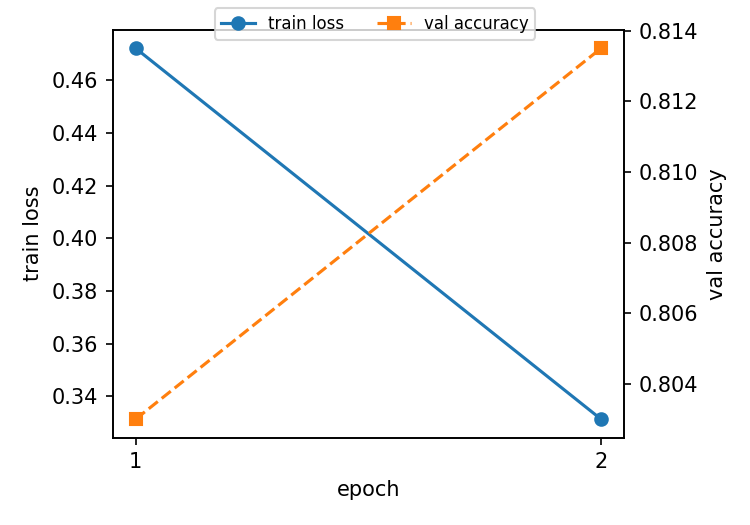

In [4]:
if RERUN:
    args = '--n-train 4000 --epochs 1' if QUICK else ''
    !python ../src/05_transformer_finetune.py {args}
print(open('../reports/transformer_finetune_report.txt').read())
display(Image('../reports/transformer_finetune_curve.png', width=380))

## Comparison on the same hand-labelled test tweets

In [5]:
a = json.load(open('../reports/transformer_pretrained_metrics.json'))
b = json.load(open('../reports/transformer_finetune_metrics.json'))
rows = [{'model': 'A: Twitter-RoBERTa (pretrained)', 'pos/neg accuracy': a['manual_binary']['accuracy'],
         'pos/neg macro-F1': a['manual_binary']['macro_f1'], '3-class accuracy': a['manual_3class']['accuracy'],
         '3-class macro-F1': a['manual_3class']['macro_f1'], 'our training data': 'none'},
        {'model': 'B: DistilBERT (fine-tuned by us)', 'pos/neg accuracy': b['manual_binary']['accuracy'],
         'pos/neg macro-F1': b['manual_binary']['macro_f1'], '3-class accuracy': None, '3-class macro-F1': None,
         'our training data': f"{b['n_train']:,} tweets, {b['epochs']} epoch(s)"}]
# The classical model (Req 2a) - add its numbers here once Jona's metrics file is in the repo
classical = '../reports/classical_metrics.json'
if os.path.exists(classical):
    c = json.load(open(classical))
    rows.append({'model': 'Classical: TF-IDF + logistic regression', **c})
pd.DataFrame(rows).set_index('model')

,pos/neg accuracy,pos/neg macro-F1,3-class accuracy,3-class macro-F1,our training data
model,,,,,
A: Twitter-RoBERTa (pretrained),0.9266,0.9264,0.8682,0.866,none
B: DistilBERT (fine-tuned by us),0.8588,0.8586,NaN,NaN,"20,000 tweets, 2 epoch(s)"


## C. Explanations: which words decided the label?  (Req 7)
Integrated Gradients gives every word a score: **green** pushed the tweet towards the predicted label, **red** pushed against it. `src/06` also checks the scores against a simple leave-one-word-out test.

In [6]:
   # Rerun only the explanations (with the Integrated Gradients fix)
   !python ../src/06_transformer_explain.py
   print(open('../reports/transformer_explain_report.txt').read())

config.json: 100% 929/929 [00:00<00:00, 3.62MB/s]
vocab.json: 100% 899k/899k [00:00<00:00, 38.2MB/s]
merges.txt: 100% 456k/456k [00:00<00:00, 99.9MB/s]
special_tokens_map.json: 100% 239/239 [00:00<00:00, 1.55MB/s]

pytorch_model.bin: downloading bytes:  58% 289M/501M [00:01<00:00, 307MB/s, 25.5MB/s  ]
pytorch_model.bin: downloading bytes:  67% 336M/501M [00:01<00:00, 278MB/s, 29.2MB/s  ]
pytorch_model.bin: downloading bytes:  79% 396M/501M [00:01<00:00, 286MB/s, 33.7MB/s  ]
pytorch_model.bin: downloading bytes:  90% 450M/501M [00:01<00:00, 277MB/s, 38.4MB/s  ]
pytorch_model.bin: reconstructing file:  80% 402M/501M [00:02<00:00, 237MB/s, 31.3MB/s  ]
pytorch_model.bin: downloading bytes: 100% 476M/476M [00:04<00:00, 114MB/s, 42.5MB/s  ]
pytorch_model.bin: reconstructing file: 100% 501M/501M [00:04<00:00, 120MB/s, 39.4MB/s  ] 
Loading weights: 100% 201/201 [00:00<00:00, 24923.29it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentimen

In [7]:
html = open('../reports/transformer_explanations.html', encoding='utf-8').read()
display(HTML(html[html.find('<h2>'):html.rfind('</body>')]))

## D. Try it on your own text (including code-switched Namibian examples, Req 6)
The model was trained on English tweets, so watch what it does with Afrikaans or Oshiwambo words.

In [8]:
from nampulse_transformer import load_model, explain, to_html
tok, model = load_model('cardiffnlp/twitter-roberta-base-sentiment-latest')
examples = [
    'Water is weer af in Windhoek, this is unacceptable, ons betaal vir niks',
    'Die diens was baie sleg and the staff were rude to everyone',
    'NamWater fixed the pipe so quickly, baie dankie!',
    'The new policy starts next month.',
]
for t in examples:
    display(HTML('<p>' + to_html(explain(t, tok, model)) + '</p>'))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Save the results
On Colab this zips every file the three scripts wrote and downloads it. Unzip it into your local NamPulse folder and commit it. The fine-tuned model in `models/` is left out because it is too big for git.

In [9]:
import shutil, glob
keep = (glob.glob('../reports/transformer_*') + glob.glob('../data/processed/transformer_*')
        + glob.glob('../data/processed/finetuned_test_predictions.csv'))
shutil.rmtree('/tmp/results', ignore_errors=True)
for f in keep:
    dest = os.path.join('/tmp/results', os.path.relpath(f, '..'))
    os.makedirs(os.path.dirname(dest), exist_ok=True)
    shutil.copy(f, dest)
shutil.make_archive('/tmp/nampulse_transformer_results', 'zip', '/tmp/results')
print(len(keep), 'files zipped:')
for f in sorted(keep):
    print('  ', os.path.relpath(f, '..'))
if IN_COLAB:
    from google.colab import files
    files.download('/tmp/nampulse_transformer_results.zip')

13 files zipped:
   data/processed/finetuned_test_predictions.csv
   data/processed/transformer_explanations.jsonl
   data/processed/transformer_predictions.csv
   data/processed/transformer_predictions.parquet
   reports/transformer_explain_report.txt
   reports/transformer_explanations.html
   reports/transformer_finetune_curve.png
   reports/transformer_finetune_metrics.json
   reports/transformer_finetune_report.txt
   reports/transformer_pretrained_confusion.png
   reports/transformer_pretrained_metrics.json
   reports/transformer_pretrained_report.txt
   reports/transformer_top_words.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What we found

*(Draft based on our results. Put it into your own words before submitting.)*

**1. The pretrained model beats our fine-tuned model.**
We tested both models on the same 354 hand-labelled positive/negative tweets:
- Model A (Twitter-RoBERTa, no training by us): 0.927 accuracy, 0.926 macro-F1.
- Model B (DistilBERT fine-tuned on 20,000 of our emoticon-labelled tweets): 0.859 accuracy, 0.859 macro-F1.

A was right and B wrong on 36 tweets; the reverse happened on only 12. An exact McNemar test gives p ≈ 0.0007, so the difference is not luck.

B did learn: validation accuracy went from 0.803 to 0.814 and training loss from 0.47 to 0.33. However, it learned from emoticon labels, which are noisy, while A was fine-tuned on human-labelled tweets. B is also weak on slang used positively. For example, it labels "Lebron is a beast... nobody in the NBA comes even close" as negative; A gets it right with 94% confidence.

**2. Three classes: 0.868 accuracy, 0.866 macro-F1 on all 493 hand-labelled tweets.**
Model A is the only one of our models that can predict neutral, because our training data has no neutral tweets.
- Neutral is the hardest class (F1 0.837).
- A leans towards positive: positive recall is 0.922 but precision only 0.846.
- 16 of 175 negative tweets and 14 of 139 neutral tweets were called positive.

**3. Where it goes wrong.**
- **Sarcasm.** For example: "Time Warner, where we make you long for the days before cable" (negative, predicted positive).
- **Tweets that mention a company but aren't about it.** For example, "Fuzzball is more fun than AT&T ;P" and "got rid of stupid time warner... Pretty good end for a monday :)".
  - The human labels seem to rate the sentiment towards the searched topic (AT&T, Time Warner).
  - The model rates the tweet as a whole.
  - This is a mismatch between our task and the labels, not only a model error.
- **Accuracy by topic.** It is lowest for AT&T (0.67), Night at the Museum (0.71) and LeBron (0.72), and highest for dentist (1.00) and jQuery (0.94).

**4. Confidence tells us when not to trust a label.**
- 9.3% of tweets have confidence below 0.6. On those, accuracy is only 0.50, compared with 0.91 for the rest.
- The dashboard therefore marks those tweets as "uncertain".
- Wrong predictions have an average confidence of 0.69, compared with 0.86 for correct ones.

**5. Tracing one output back to its words (explainability).**
- "Nancy Pelosi gave the worst commencement speech I've ever heard. Yes I'm still bitter about this" is predicted negative (96%).
  - Integrated Gradients gives "worst" the highest score (1.00), followed by "bitter" (0.23).
  - Names like "Nancy" and "commencement" score close to 0 or slightly against.
- Across all tweets, the words that push towards each label make sense:
  - **Negative:** sad, worst, sucks, stupid, fail, hate.
  - **Positive:** fun, amazing, excited, awesome, great, love.
  - **Neutral:** mostly topic words such as safeway, twitter, api and rt. The model treats a tweet without emotional words as neutral.
- There are two oddities:
  - "can't" scores as positive, because of "can't wait".
  - "d" comes from the ":D" smiley being split into pieces.
- **Checks:**
  - The Integrated Gradients scores agree with a simple leave-one-word-out test (mean Spearman ρ = 0.61; same most important word in 50% of tweets).
  - The scores should add up to the change in the model's output. They do for 415 of 493 tweets (84%, gap ≤ 0.05).
  - For the other 78 tweets, the word scores are only approximate. Adding more integration steps did not fix these, which points to gradient spikes in the embedding layer.
  - Measuring the words after the embedding block, and flagging tweets whose scores still don't add up, is the planned next improvement.

**6. Mixed languages (Req 6).**
Model A agrees with the emoticon labels on:
- 0.775 of the tweets not flagged as mixed-language
- 0.688 of code-switched tweets
- 0.590 of the 139 tweets in other languages

It was trained on English tweets, and it has never seen Oshiwambo.

**7. Bias and data-quality risks.**
- **Old US data.** The data is from April–June 2009 and is mostly US English, about US brands and politicians. Results may not carry over to Namibian social media today.
- **Noisy training labels.** Model B's training labels come from emoticons.
- **Test labels measure something slightly different.** They appear to be labelled towards the searched topic.
- **Possible training overlap.** We could not fully confirm that model A never saw our test tweets during its original training.